**1. Load the given road accident dataset and display the first 10 rows. List all numerical and categorical variables separately. Check the data types of all columns and interpret whether any column needs type conversion.**

In [56]:
import pandas as pd

In [96]:
# loading the road accident dataset

data = pd.read_csv('QP_Data_road_accident_dataset_with_missing.csv')

# changing all column names to lowercase and replacing spaces with underscores
data.columns = data.columns.str.lower().str.replace(' ', '_')

# displaying first 10 rows
data.head(10)

,country,year,month,day_of_week,time_of_day,urban/rural,road_type,weather_conditions,visibility_level,number_of_vehicles_involved,...,number_of_fatalities,emergency_response_time,traffic_volume,road_condition,accident_cause,insurance_claims,medical_cost,economic_loss,region,population_density
0,USA,2002,October,Tuesday,Evening,Rural,Street,Windy,NaN,1,...,2,58.625720,7412.752760,Wet,Weather,4,40499.856980,22072.878500,Europe,3866.273014
1,UK,2014,December,Saturday,Evening,Urban,Street,Windy,168.311358,3,...,1,58.041380,4458.628820,Snow-covered,Mechanical Failure,3,6486.600073,9534.399441,North America,2333.916224
2,USA,2012,July,Sunday,Afternoon,Urban,Highway,Snowy,341.286506,4,...,4,NaN,9856.915064,Wet,Speeding,4,29164.412980,58009.145120,South America,4408.889129
3,UK,2017,May,Saturday,Evening,Urban,Main Road,Clear,489.384536,2,...,3,48.554014,4958.646267,Icy,Distracted Driving,3,25797.212570,20907.151300,Australia,2810.822423
4,Canada,2002,July,Tuesday,Afternoon,Rural,Highway,Rainy,348.344850,1,...,4,18.318250,3843.191463,Icy,Distracted Driving,8,15605.293920,13584.060760,South America,3883.645634
5,India,2010,May,Monday,Evening,Urban,Street,Snowy,479.216834,2,...,4,8.205994,360.951795,Dry,Speeding,7,NaN,45995.605250,South America,3626.074027
6,China,2010,March,Monday,Afternoon,Rural,Street,Foggy,386.176217,3,...,3,17.851663,7607.804705,Wet,Weather,9,NaN,52342.431810,Asia,3408.182341
7,USA,2016,July,Friday,Afternoon,Rural,Main Road,Foggy,75.608688,3,...,2,46.740367,6061.407002,Dry,Speeding,8,4262.755621,70652.223520,South America,408.296453
8,Japan,2014,August,Thursday,Afternoon,Rural,Highway,Rainy,387.828675,3,...,2,NaN,3793.850542,Snow-covered,Mechanical Failure,5,37624.775980,13724.630950,Europe,2058.898279
9,USA,2007,April,Monday,Evening,Urban,Highway,Foggy,443.965408,3,...,3,NaN,1140.429308,Snow-covered,Distracted Driving,0,15801.190080,61948.862750,Australia,1840.206143


In [58]:
# listing numerical and categorical columns in the dataset separately
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: ['year', 'visibility_level', 'number_of_vehicles_involved', 'speed_limit', 'driver_alcohol_level', 'driver_fatigue', 'pedestrians_involved', 'cyclists_involved', 'number_of_injuries', 'number_of_fatalities', 'emergency_response_time', 'traffic_volume', 'insurance_claims', 'medical_cost', 'economic_loss', 'population_density']
Categorical Columns: ['country', 'month', 'day_of_week', 'time_of_day', 'urban/rural', 'road_type', 'weather_conditions', 'driver_age_group', 'driver_gender', 'vehicle_condition', 'accident_severity', 'road_condition', 'accident_cause', 'region']


In [59]:
# checking datatypes of columns

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   country                      132000 non-null  object 
 1   year                         132000 non-null  int64  
 2   month                        132000 non-null  object 
 3   day_of_week                  132000 non-null  object 
 4   time_of_day                  132000 non-null  object 
 5   urban/rural                  132000 non-null  object 
 6   road_type                    132000 non-null  object 
 7   weather_conditions           132000 non-null  object 
 8   visibility_level             125400 non-null  float64
 9   number_of_vehicles_involved  132000 non-null  int64  
 10  speed_limit                  132000 non-null  int64  
 11  driver_age_group             132000 non-null  object 
 12  driver_gender                132000 non-null  object 
 13 

With this list, we can see the data types and null values (if any) of all the columns.

In the later part of this task, we will be using accident_severity for a lot of tasks which will give better results if the column is encoded. Thus, we will encode it using label encoding. 

0 -> minor

1 -> moderate

2 -> severe

In [105]:
# encode accident severity using label encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['accident_severity'] = le.fit_transform(data['accident_severity'])

**2. (a) Generate descriptive statistics for all numerical variables. Which variable shows the highest variation?**

In [61]:
# descriptive statistics of numerical columns
data[numerical_columns].describe()

,year,visibility_level,number_of_vehicles_involved,speed_limit,driver_alcohol_level,driver_fatigue,pedestrians_involved,cyclists_involved,number_of_injuries,number_of_fatalities,emergency_response_time,traffic_volume,insurance_claims,medical_cost,economic_loss,population_density
count,132000.000000,125400.000000,132000.000000,132000.000000,104893.000000,132000.000000,132000.000000,132000.000000,132000.000000,132000.000000,118824.000000,125400.000000,132000.000000,106979.000000,118800.000000,125400.000000
mean,2011.973348,275.104755,2.501227,74.544068,0.110463,0.500576,1.000773,0.998356,9.508205,1.995439,32.486666,5039.695672,4.495621,22999.326535,46028.388017,2505.985119
std,7.198624,129.946180,1.117272,26.001448,0.066818,0.500002,0.816304,0.817764,5.774366,1.412974,15.900793,2861.300571,2.867347,13309.840366,26642.146034,1441.036753
min,2000.000000,50.001928,1.000000,30.000000,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,5.000177,100.062626,0.000000,500.110091,1000.335085,10.002669
25%,2006.000000,162.422604,2.000000,52.000000,0.053893,0.000000,0.000000,0.000000,5.000000,1.000000,18.694200,2554.836546,2.000000,11594.699610,23253.528405,1257.505421
50%,2012.000000,274.808977,3.000000,74.000000,0.107667,1.000000,1.000000,1.000000,9.000000,2.000000,32.549514,5033.213155,4.000000,22687.634120,45484.381415,2504.196516
75%,2018.000000,388.070736,3.000000,97.000000,0.161436,1.000000,2.000000,2.000000,15.000000,3.000000,46.288919,7523.931508,7.000000,33869.677745,67731.981662,3757.099191
max,2024.000000,499.999646,4.000000,119.000000,0.249989,1.000000,2.000000,2.000000,19.000000,4.000000,59.999588,9999.997468,9.000000,49999.930130,99999.622970,4999.991745


Variation of a field around the mean can be analyzed through the standard deviation. In this dataset, the variable with highest variation is economic_loss (std_dev = 26642.14) followed by medical_cost. 

**2 (b) Compare the mean and median of Medical Cost. What does the difference indicate about Skewness?**

In [62]:
# comparing mean and median oi Medical Cost. 

print("Mean of Medical Cost:", data['medical_cost'].mean())
print("Median of Medical Cost:", data['medical_cost'].median())


Mean of Medical Cost: 22999.326534801297
Median of Medical Cost: 22687.63412


The mean and median of Medial Cost are almost equal. This suggests that the distribution is almost a normal distribution without any skewness.
As a proof, a histogram has been plotted below

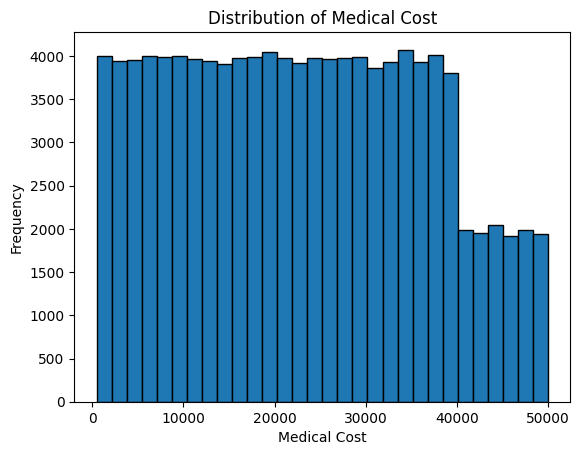

In [63]:
# histogram of Medical Cost
import matplotlib.pyplot as plt

plt.hist(data['medical_cost'], bins=30, edgecolor='black')
plt.xlabel('Medical Cost')
plt.ylabel('Frequency')
plt.title('Distribution of Medical Cost')
plt.show()

**3. (a) Identify all variables containing missing values. Calculate the number and percentage of missing values in each column.**

In [97]:
# missing values

missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Columns with missing values:")
print(missing_values)

Columns with missing values:
visibility_level            6600
driver_alcohol_level       27107
emergency_response_time    13176
traffic_volume              6600
medical_cost               25021
economic_loss              13200
population_density          6600
dtype: int64


In [98]:
# percentage of missing values in each column
missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
print("Percentage of missing values in each column:")
print(missing_percentage)

Percentage of missing values in each column:
visibility_level            5.000000
driver_alcohol_level       20.535606
emergency_response_time     9.981818
traffic_volume              5.000000
medical_cost               18.955303
economic_loss              10.000000
population_density          5.000000
dtype: float64


**3. (b) Explain and identify which missing value technique can be used for variables Visibility Level, Traffic Volume, and Population Density.**

For Visibility, we can replace the missing values with the mean of that categpry in Weather Condition column. 
This is because the visibility is likely to be affected by the weather condition, and using the mean of that category can provide a more accurate estimate of the missing values.

In [99]:
# visibility level
mean_visibility_by_weather = data.groupby('weather_conditions')['visibility_level'].transform('mean')
data['visibility_level'] = data['visibility_level'].fillna(mean_visibility_by_weather)

In [67]:
data[['weather_conditions', 'visibility_level']].head(70)

,weather_conditions,visibility_level
0,Windy,275.196476
1,Windy,168.311358
2,Snowy,341.286506
3,Clear,489.384536
4,Rainy,348.344850
...,...,...
65,Rainy,423.431896
66,Clear,145.168029
67,Foggy,274.479201
68,Rainy,357.406796


For traffic volume and population density, we can just replace missing values with the mean of the column.


In [100]:
# traffic volume
data['traffic_volume'] = data['traffic_volume'].fillna(data['traffic_volume'].mean())

In [101]:
# population density
data['population_density'] = data['population_density'].fillna(data['population_density'].mean())

**3. (c) Explain and identify which missing value technique can be used for variables Driver Alcohol Level, Emergency Response Time, and Medical Cost.**

In [72]:
# handling missing values for driver alchol level, we can replace missing values by taking mean of their category in ['driver_age', 'driver_gender']
data['driver_alcohol_level'] = data.groupby(['driver_age_group', 'driver_gender'])['driver_alcohol_level'].transform(lambda x: x.fillna(x.mean()))

In [73]:
# for emergency response time, we can replace missing values with the mean of the column.
data['emergency_response_time'] = data['emergency_response_time'].fillna(data['emergency_response_time'].mean())

In [74]:
# for medical cost, we can replace missing values with the mean of that category in accident cause column. 
mean_cost_by_cause = data.groupby('accident_cause')['medical_cost'].transform('mean')
data['medical_cost'] = data['medical_cost'].fillna(mean_cost_by_cause)

**d. How can missingness in Driver Alcohol Level be both MAR and MNAR? Explain with reference to the dataset.**

**4. (a) Plot a chart showing accidents by Weather Condition,Road Type and Accident Severity.**

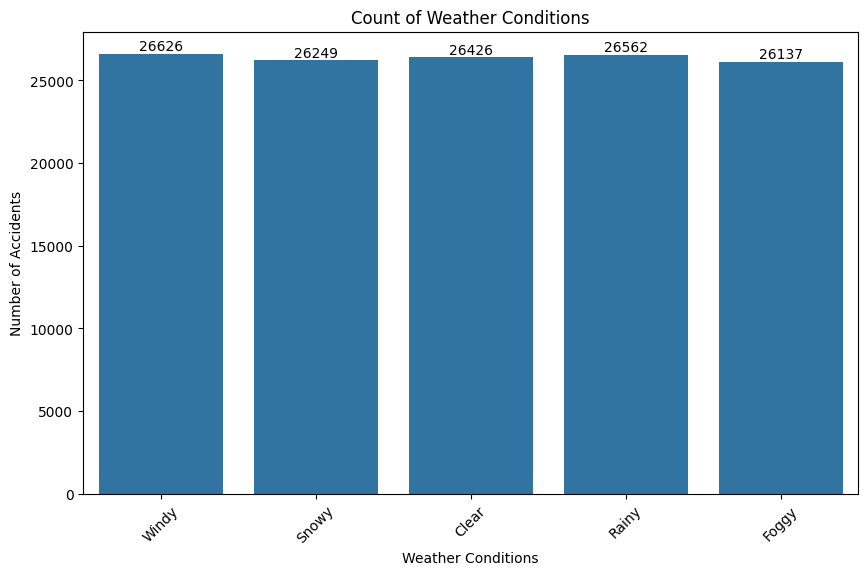

In [103]:
import seaborn as sns
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='weather_conditions', data=data)
plt.title('Count of Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)
plt.show()





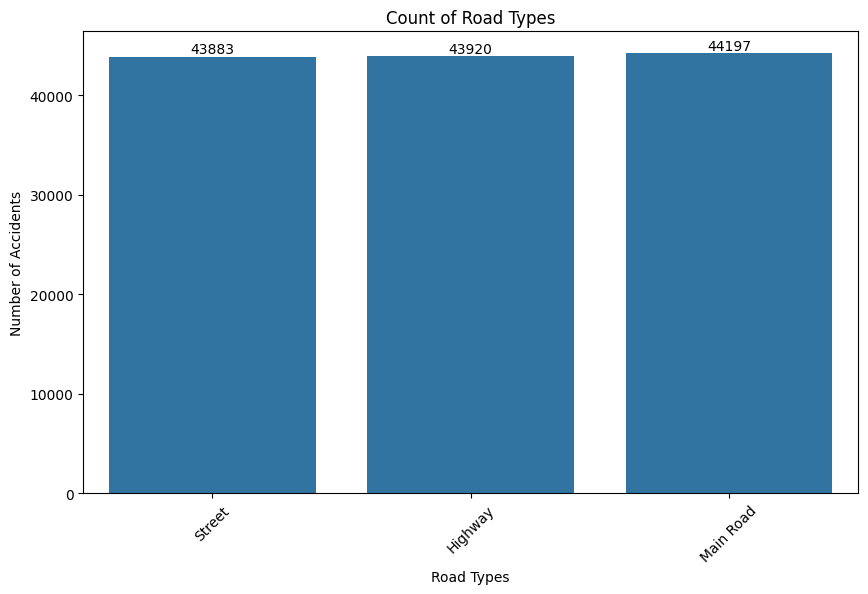

In [93]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='road_type', data=data)
plt.title('Count of Road Types')
plt.xlabel('Road Types')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)
plt.show()

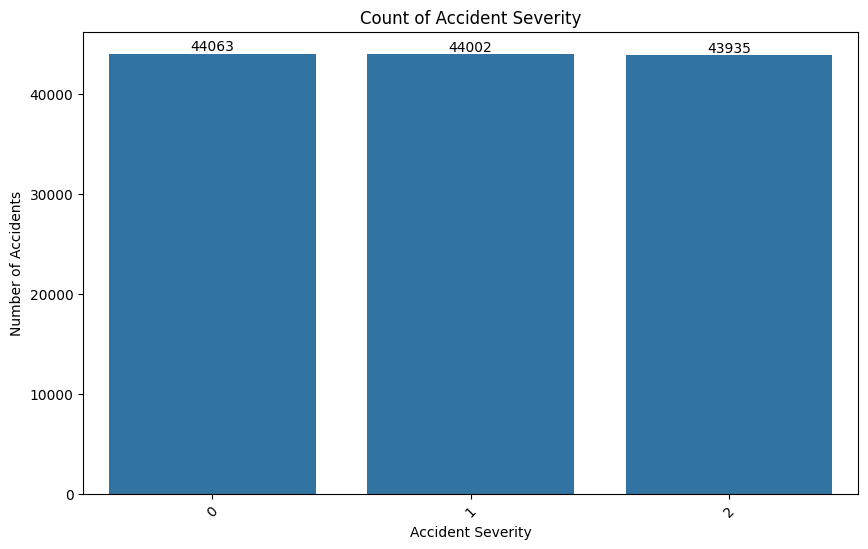

In [95]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='accident_severity', data=data)
plt.title('Count of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')

for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)
plt.show()

**4. (b) Plot a boxplot for Economic Loss, Medical Cost grouped by Accident Severity.**

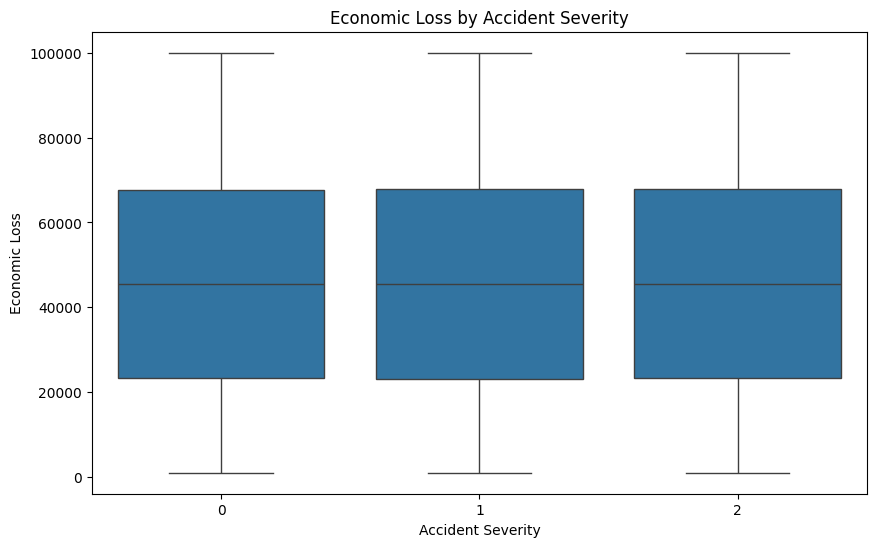

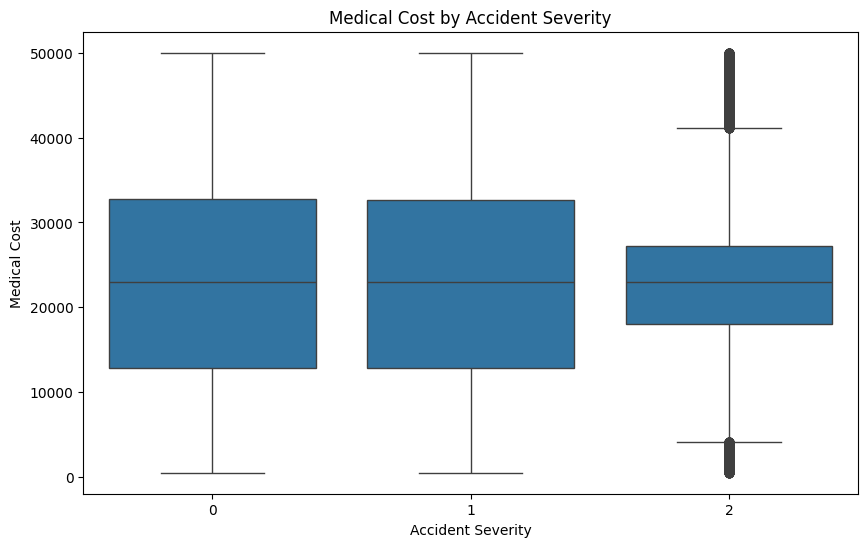

In [76]:
#Boxplot for Economic Loss, Medical Cost grouped by Accident Severity.

plt.figure(figsize=(10, 6))
sns.boxplot(x='accident_severity', y='economic_loss', data=data)
plt.title('Economic Loss by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Economic Loss')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='accident_severity', y='medical_cost', data=data)
plt.title('Medical Cost by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Medical Cost')
plt.show()


**4. (c) Plot a scatter plot between Traffic Volume and Accident Severity / Economic Loss.**

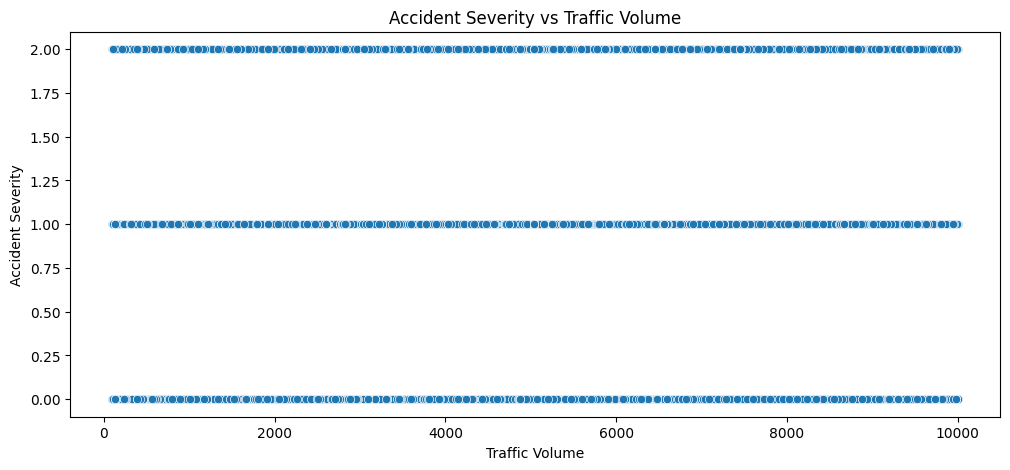

In [77]:
#scatter plot between Traffic Volume and Accident Severity 

plt.figure(figsize=(12, 5))
sns.scatterplot(x='traffic_volume', y='accident_severity', data=data)
plt.title('Accident Severity vs Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Accident Severity')

plt.show()


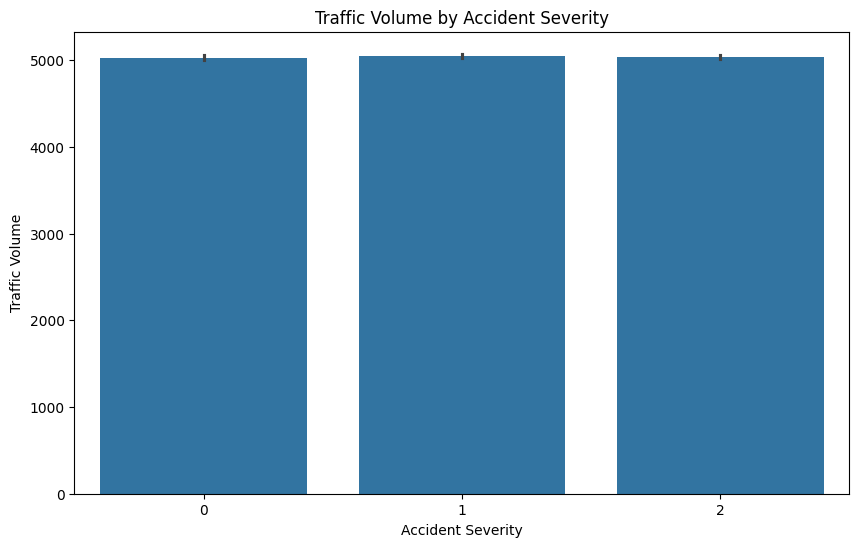

In [78]:
# bar plot for accident severity and traffic volume

plt.figure(figsize=(10, 6))
sns.barplot(x='accident_severity', y='traffic_volume', data=data)
plt.title('Traffic Volume by Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Traffic Volume')
plt.show()

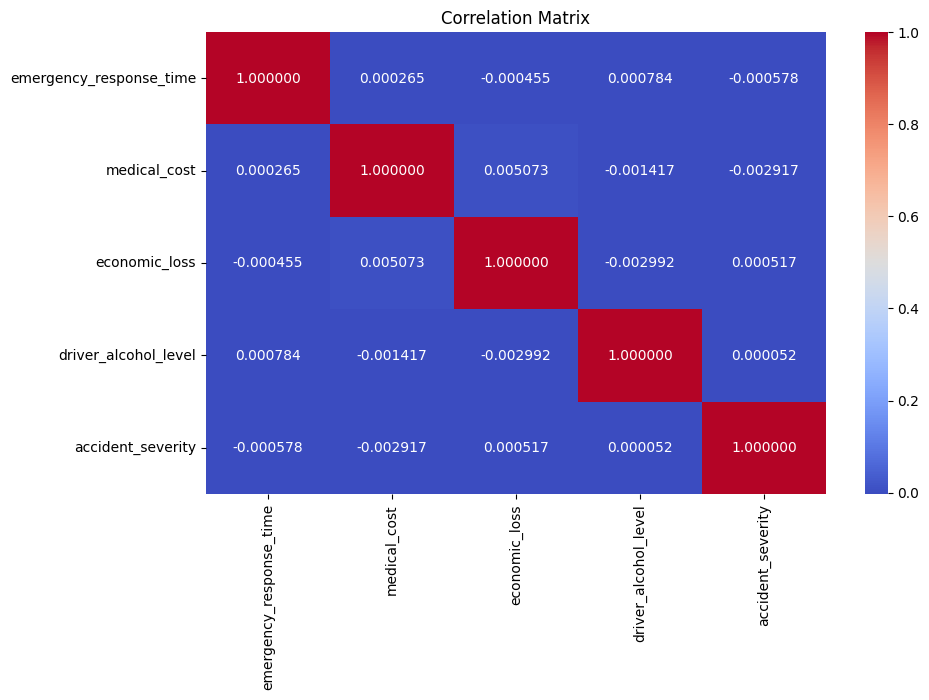

In [106]:
correlation_matrix = data[['emergency_response_time', 'medical_cost', 'economic_loss', 'driver_alcohol_level', 'accident_severity']].corr()

#plot correlation matrix using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".6f")
plt.title('Correlation Matrix')
plt.show()


All correlations are very weak so they don't suggest any major relationships between these variables.

**6. (a) Use the IQR method to identify outliers for Medical Cost, Economic Loss, Traffic Volume and Emergency Response Time.**

In [ ]:

def identify_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

print("Outliers in Medical Cost:")
outliers_medical_cost = identify_outliers_iqr(data, 'medical_cost')
print(outliers_medical_cost.shape[0])

print("Outliers in Economic Loss:")
outliers_economic_loss = identify_outliers_iqr(data, 'economic_loss')
print(outliers_economic_loss.shape[0])

print("Outliers in Traffic Volume:")
outliers_traffic_volume = identify_outliers_iqr(data, 'traffic_volume')
print(outliers_traffic_volume.shape[0])

print("Outliers in Emergency Response Time:")
outliers_emergency_response_time = identify_outliers_iqr(data, 'emergency_response_time')
print(outliers_emergency_response_time.shape[0])

Outliers in Medical Cost:
0
Outliers in Economic Loss:
0
Outliers in Traffic Volume:
0
Outliers in Emergency Response Time:
0


**Environmental and road conditions impacting accident**